<a href="https://colab.research.google.com/github/Pedro4Albuquerque/am-t4-s1a2026t2/blob/main/RandomForestCensus0608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Rondom Forest | Digest Pickle [Fase 1 - census Base]

## Importar dados do Drive

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [71]:
!pip -q install plotly
!pip -q install yellowbrick

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [73]:
import pickle

In [74]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [75]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [76]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [79]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [81]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [82]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [83]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

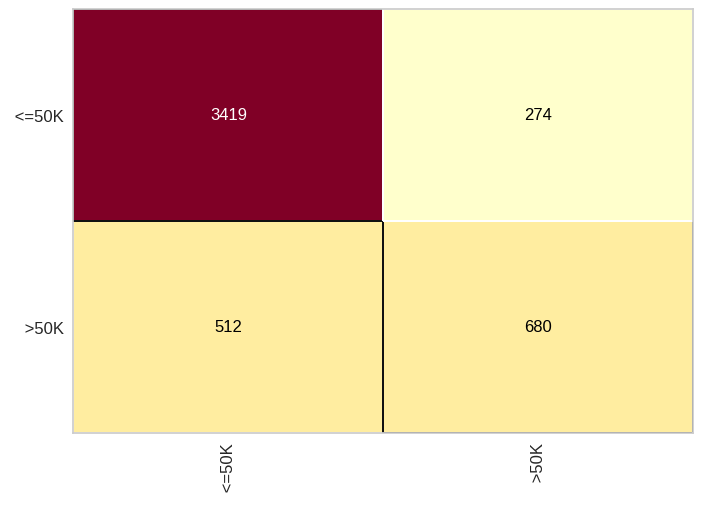

In [84]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [85]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885

